# MLIA PS2 Solution
### By Sravanth Chowdary Potluri und5uv


### Question 1

#### Part (a)
Euler’s method: https://en.wikipedia.org/wiki/Euler_method
For $$\frac{dy}{dt}+ 2y= 2−e^{−4t},y(0) = 1$$

Derive its closed-form solution on your own.

Solution:

To solve the initial value problem:

$$
\frac{dy}{dt} + 2y = 2 - e^{-4t}, \quad y(0) = 1,
$$

we will use the integrating factor method for linear first-order ordinary differential equations (ODEs).

**Step 1: Identify $ P(t) $ and $ Q(t) $**

The given ODE is in the standard linear form:

$$
\frac{dy}{dt} + P(t) y = Q(t),
$$

where $ P(t) = 2 $ and $ Q(t) = 2 - e^{-4t} $.

**Step 2: Compute the Integrating Factor $ \mu(t) $**

The integrating factor $ \mu(t) $ is:

$$
\mu(t) = e^{\int P(t) dt} = e^{\int 2 dt} = e^{2t}.
$$

**Step 3: Multiply Both Sides by the Integrating Factor**

Multiply the entire ODE by $ \mu(t) $:

$$
e^{2t} \frac{dy}{dt} + 2 e^{2t} y = [2 - e^{-4t}] e^{2t}.
$$

**Step 4: Simplify the Left-Hand Side (LHS)**

It is known from the method that the LHS is the derivative of $ e^{2t} y $:

$$
\frac{d}{dt} [e^{2t} y] = [2 - e^{-4t}] e^{2t}.
$$

**Step 5: Simplify the Right-Hand Side (RHS)**

Simplify the RHS:

$$
[2 - e^{-4t}] e^{2t} = 2 e^{2t} - e^{-4t} e^{2t} = 2 e^{2t} - e^{-2t}.
$$

**Step 6: Integrate Both Sides**

Integrate both sides with respect to $ t $:

$$
\int \frac{d}{dt} [e^{2t} y] dt = \int \left(2 e^{2t} - e^{-2t}\right) dt.
$$

Compute the integrals:

$$
e^{2t} y = \int 2 e^{2t} dt - \int e^{-2t} dt + C,
$$

$$
e^{2t} y = e^{2t} + \frac{1}{2} e^{-2t} + C.
$$

**Step 7: Solve for $ y(t) $**

Divide both sides by $ e^{2t} $:

$$
y(t) = 1 + \frac{1}{2} e^{-4t} + C e^{-2t}.
$$

**Step 8: Apply the Initial Condition**

Use $ y(0) = 1 $ to find $ C $:

$$
1 = 1 + \frac{1}{2} e^{0} + C e^{0} \implies 1 = 1 + \frac{1}{2} + C.
$$

Solve for $ C $:

$$
C = -\frac{1}{2}.
$$

**Step 9: Write the Final Solution**

Substitute $ C $ back into the equation:

$$
y(t) = 1 + \frac{1}{2} e^{-4t} - \frac{1}{2} e^{-2t}.
$$

**Simplified Form:**

$$
y(t) = 1 + \frac{1}{2} \left( e^{-4t} - e^{-2t} \right).
$$

**Final Answer:**

The closed-form solution is:

$$
\boxed{y(t) = 1 + \dfrac{1}{2} \left( e^{-4t} - e^{-2t} \right)}
$$


reference: https://www.sfu.ca/math-coursenotes/Math%20158%20Course%20Notes/sec_first_order_homogeneous_linear.html

#### Part (b)
Use Euler’s Method to find the approximation to the solution at t= {1,2,3,4,5}, and
compare to the exact solution in (a) by plotting them on a same figure.

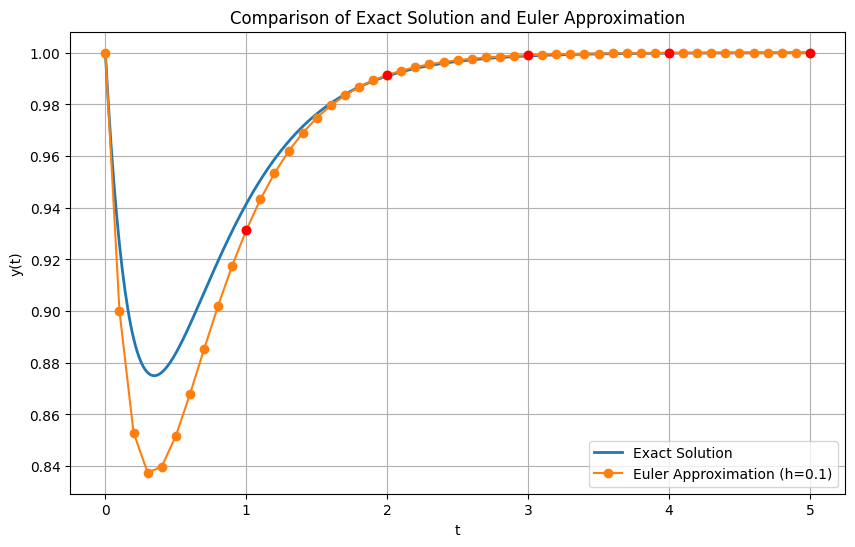

t	Euler Approx	Exact Solution
1	0.931324		0.941490
2	0.991368		0.991010
3	0.999050		0.998764
4	0.999898		0.999832
5	0.999989		0.999977


In [251]:
import numpy as np
import matplotlib.pyplot as plt


# Define the differential equation dy/dt = f(t, y)
def f(t, y):
    return 2 - np.exp(-4 * t) - 2 * y

# Exact solution of the differential equation
def exact_solution(t):
    return 1 + 0.5 * (np.exp(-4 * t) -np.exp(-2 * t))

# Euler's Method implementation
def euler_method(f, t0, y0, h, t_end):
    N = int((t_end - t0) / h) + 1  # Number of steps
    t = np.linspace(t0, t_end, N)
    y = np.zeros(N)
    y[0] = y0

    for n in range(N - 1):
        y[n + 1] = y[n] + h * f(t[n], y[n])

    return t, y

# Part (b): Approximation at t = {1, 2, 3, 4, 5}
t0 = 0
y0 = 1
h = 0.1
t_end = 5

t_euler, y_euler = euler_method(f, t0, y0, h, t_end)
t_exact = np.linspace(t0, t_end, 500)
y_exact = exact_solution(t_exact)

# Extract approximate values at t = {1, 2, 3, 4, 5}
t_values = np.array([1, 2, 3, 4, 5])
indices = (t_values / h).astype(int)
y_approx = y_euler[indices]
y_actual = exact_solution(t_values)

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(t_exact, y_exact, label='Exact Solution', linewidth=2)
plt.plot(t_euler, y_euler, 'o-', label='Euler Approximation (h=0.1)')
plt.scatter(t_values, y_approx, color='red', zorder=5)
plt.title('Comparison of Exact Solution and Euler Approximation')
plt.xlabel('t')
plt.ylabel('y(t)')
plt.legend()
plt.grid(True)
plt.show()

# Print the approximate and exact values at t = {1, 2, 3, 4, 5}
print("t\tEuler Approx\tExact Solution")
for t_val, y_eul, y_ex in zip(t_values, y_approx, y_actual):
    print(f"{t_val}\t{y_eul:.6f}\t\t{y_ex:.6f}")
    


#### Part (c)
Use diﬀerent step size h= {0.1,0.05,0.01,0.005,0.001}and plot out your approximated
function value.

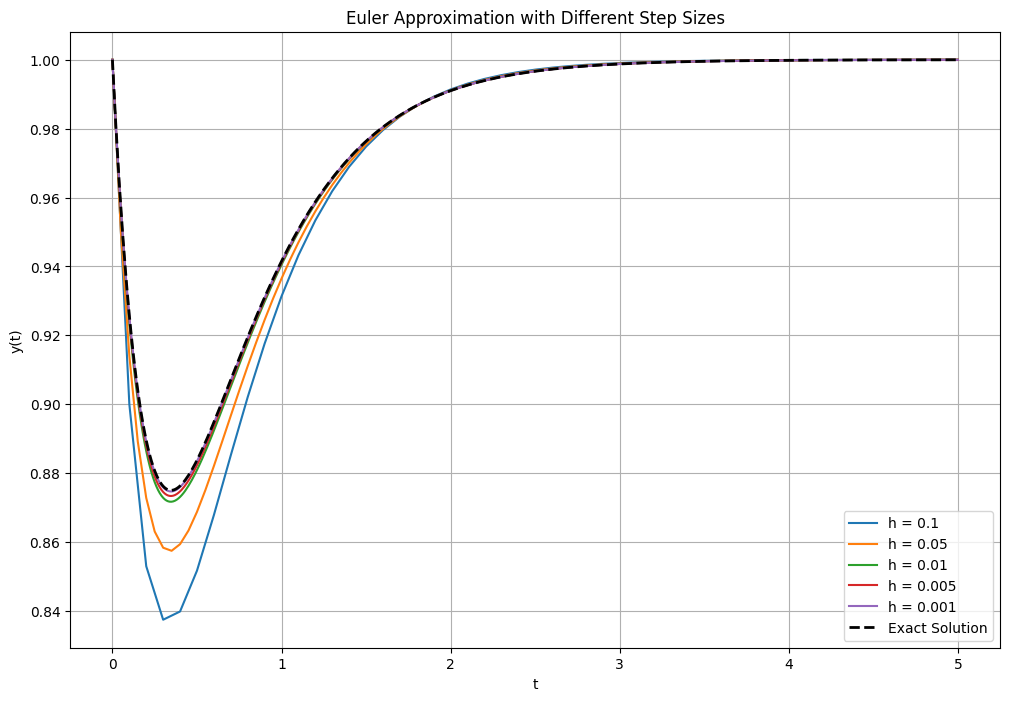

In [252]:
# Part (c): Euler's Method with different step sizes
step_sizes = [0.1, 0.05, 0.01, 0.005, 0.001]
plt.figure(figsize=(12, 8))

for h in step_sizes:
    t_euler, y_euler = euler_method(f, t0, y0, h, t_end)
    plt.plot(t_euler, y_euler, label=f'h = {h}')

# Plot exact solution
plt.plot(t_exact, y_exact, 'k--', label='Exact Solution', linewidth=2)

plt.title('Euler Approximation with Different Step Sizes')
plt.xlabel('t')
plt.ylabel('y(t)')
plt.legend()
plt.grid(True)
plt.show()


#### You can observe that as the step size $ h $ decreases, the Euler approximation becomes closer to the exact solution. This is because a smaller step size allows the method to take smaller increments and better approximate the behavior of the function over the interval.

### Question 2

Generating time-sequential images with geodesic shooting equations. Given an initial velocity, implement geodesic shooting algorithm (via Euler integration) to generate a time-sequence of deformations (transformations), $\phi_t,t ∈[0,···,1]$. You will then deform a given source image (included in the data folder) by using the final transformation $\phi_1$ at time point $t=1$.
Note that the initial condition $v_0$ is given in the data folder, and the initial condition for $\phi_0$
is an image coordinate of the given source image, which can be easily generated from Python
(e.g., numpy’s meshgrid).

#### Part (a)
Implement and compute the geodesic shooting equation below (a special case of the original shooting equation discussed in class) using Euler integration with 10 time steps,e.g., t= {0,0.1,0.2,···,1}.
$$
\frac{dv_t}{dt} = -K[(Dv_t)^T \cdot v_t + (Dv_t) \cdot v_t + v_t \cdot \text{div}(v_t)],
$$
$$
\frac{d\phi_t}{dt} = v_t \circ \phi_t,
$$
where K is a smoothing kernel (e.g., a Gaussian smoothing kernel), D is a Jacobian
matrix, div is a divergence operator, and $\circ$ denotes an interpolation.

In [253]:
import numpy as np
import scipy.ndimage
import matplotlib.pyplot as plt
import time

#### Loading the source image and initial velocity field and displaying them

In [254]:
import torch

data_folder = 'data'  # Replace with the path to your data folder
s = torch.load('PS2_Q2/code+data/source.pt').numpy() 
v0 = np.transpose(torch.load('PS2_Q2/code+data/v0.pt').numpy(), (1, 2, 0))

/var/folders/_r/qvq82mn570z3cjtf48bv_fgc0000gn/T/ipykernel_32821/2433952859.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  s = torch.load('PS2_Q2/code+data/source.pt').

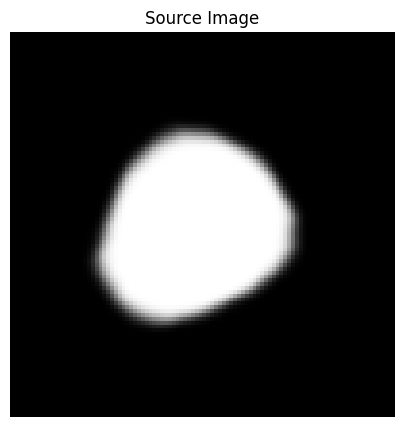

In [255]:
# Displaying the source image
plt.figure(figsize=(5, 5))
plt.imshow(s, cmap='gray')
plt.title('Source Image')
plt.axis('off')
plt.show()

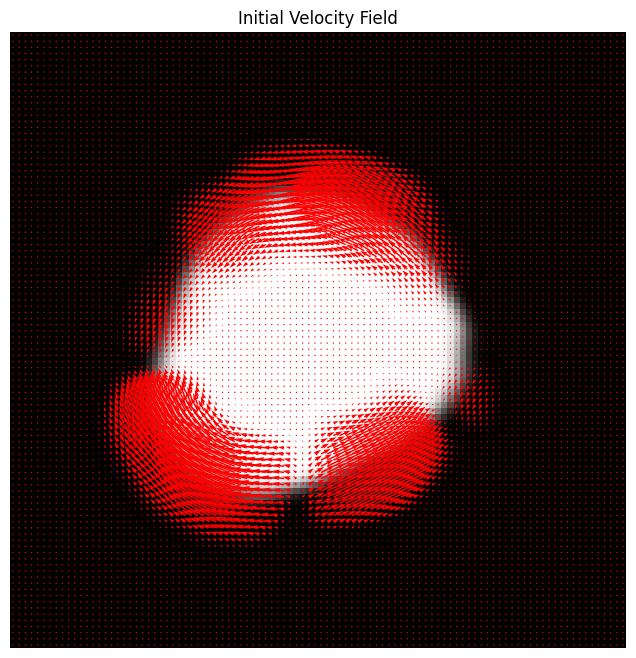

In [256]:
# plotting the velocity field as a vector field
plt.figure(figsize=(8, 8))
plt.imshow(s, cmap='gray')
plt.quiver(v0[..., 1], v0[..., 0], color='red')
plt.title('Initial Velocity Field')
plt.axis('off')
plt.show()

#### The velocity field vector plot shows the initial velocity field $v_0$ as a vector field over the source image. The red arrows represent the direction and magnitude of the velocity at each point in the image. The field shows the direction in which each point in the image will move over time.

#### Generating the initial transformation $\phi_0$ which is the image coordinates (identity mapping)

In [257]:
# Generate the coordinate grid for the image
height, width = s.shape
y_coords, x_coords = np.meshgrid(np.arange(height), np.arange(width), indexing='ij')

# Setting the initial transformation phi_0 as the image coordinates
phi0 = np.stack((y_coords, x_coords), axis=-1)


#### Define the functions and utilities for the geodesic shooting algorithm

In [258]:
def compute_jacobian(v):
    """
    Compute the Jacobian matrices Dv of the velocity field v.
    v: Velocity field of shape (H, W, 2)
    Returns:
        Dv: Jacobian matrices of shape (H, W, 2, 2)
    """
    dv_dy = np.gradient(v[:, :, 0], axis=0)
    dv_dx = np.gradient(v[:, :, 1], axis=1)
    du_dy = np.gradient(v[:, :, 0], axis=0)
    du_dx = np.gradient(v[:, :, 0], axis=1)

    Dv = np.zeros((v.shape[0], v.shape[1], 2, 2))
    Dv[:, :, 0, 0] = du_dy  # dv_y/dy
    Dv[:, :, 0, 1] = du_dx  # dv_y/dx
    Dv[:, :, 1, 0] = dv_dy  # dv_x/dy
    Dv[:, :, 1, 1] = dv_dx  # dv_x/dx

    return Dv

def compute_divergence(v):
    """
    Compute the divergence of the velocity field v.
    v: Velocity field of shape (H, W, 2)
    Returns:
        div_v: Divergence of shape (H, W)
    """
    dv_dy = np.gradient(v[:, :, 0], axis=0)
    dv_dx = np.gradient(v[:, :, 1], axis=1)
    div_v = dv_dy + dv_dx
    return div_v

def apply_smoothing_kernel(F, sigma=1.0):
    """
    Apply a Gaussian smoothing kernel to the field F.
    F: Field to be smoothed (can be multi-dimensional)
    sigma: Standard deviation for Gaussian kernel
    Returns:
        Smoothed field
    """
    smoothed_F = np.zeros_like(F)
    for i in range(F.shape[-1]):
        smoothed_F[..., i] = scipy.ndimage.gaussian_filter(F[..., i], sigma=sigma, mode='reflect')
    return smoothed_F

def interpolate(v, phi):
    """
    Interpolate the velocity field v at positions phi.
    v: Velocity field of shape (H, W, 2)
    phi: Positions where to interpolate v, shape (H, W, 2)
    Returns:
        Interpolated velocity field at phi, shape (H, W, 2)
    """
    v_interpolated = np.zeros_like(v)
    for i in range(2):
        v_interpolated[..., i] = scipy.ndimage.map_coordinates(
            v[..., i],
            [phi[..., 0], phi[..., 1]],
            order=3,
            mode='reflect'
        )
    return v_interpolated


#### Implementing the geodesic shooting algorithm using Euler integration and storing the velocity and deformation fields at each time step

In [259]:
# Parameters
num_time_steps = 10
delta_t = 1.0 / num_time_steps
time_points = np.linspace(0, 1, num_time_steps + 1)
sigma_smoothing = 1.0  # Standard deviation for the Gaussian smoothing kernel

# Initialize variables
vt = v0.copy()
phit = phi0.copy()

# To store intermediate results
vt_sequence = [vt.copy()]
phit_sequence = [phit.copy()]
deformed_images = []

# Start timing
start_time = time.time()

# Euler integration loop
for t_idx in range(num_time_steps):
    print(f"Time step {t_idx+1}/{num_time_steps}")

    # Compute the Jacobian Dvt
    Dvt = compute_jacobian(vt)

    # Compute divergence of vt
    div_vt = compute_divergence(vt)

    # Compute the right-hand side of the velocity equation
    # (Dv_t)^T · v_t
    Dvt_T_vt = np.einsum('...ji,...j->...i', Dvt, vt)

    # (Dv_t) · v_t
    Dvt_vt = np.einsum('...ij,...j->...i', Dvt, vt)

    # v_t · div(v_t)
    vt_div_vt = vt * div_vt[..., np.newaxis]

    # Sum the terms
    F_t = Dvt_T_vt + Dvt_vt + vt_div_vt

    # Apply the smoothing kernel K[F_t]
    K_F_t = apply_smoothing_kernel(F_t, sigma=sigma_smoothing)

    # Update the velocity field vt
    vt = vt - delta_t * K_F_t

    # Interpolate vt over phit
    vt_phi = interpolate(vt, phit)

    # Update the transformation phit
    phit = phit + delta_t * vt_phi

    # Store intermediate results
    vt_sequence.append(vt.copy())
    phit_sequence.append(phit.copy())

    # Deform the source image
    deformed_image = scipy.ndimage.map_coordinates(
        s,
        [phit[..., 0], phit[..., 1]],
        order=3,
        mode='reflect'
    )
    deformed_images.append(deformed_image)

# End timing
end_time = time.time()


Time step 1/10
Time step 2/10
Time step 3/10
Time step 4/10
Time step 5/10
Time step 6/10
Time step 7/10
Time step 8/10
Time step 9/10
Time step 10/10


#### Part (b)

Report the final velocity vt=1 and a time-sequence of deformed source image s by computing $s◦\phi_t$.

#### Displaying the final velocity field at t=1 and the time-sequence of deformed images

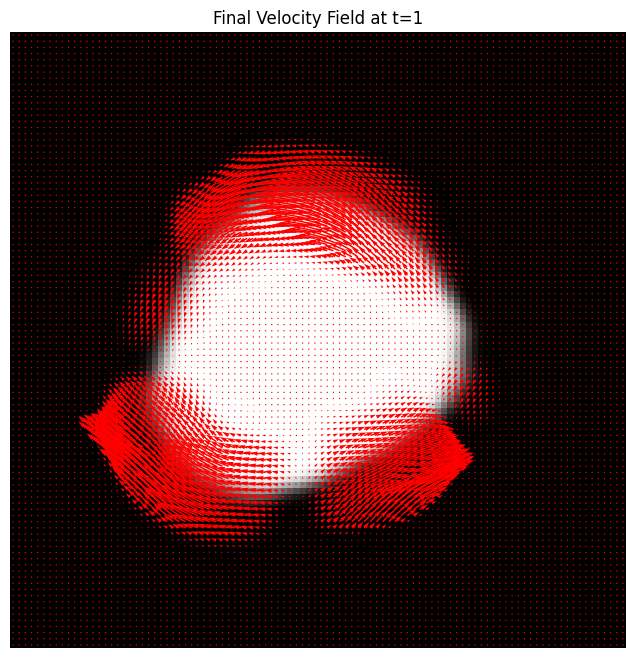

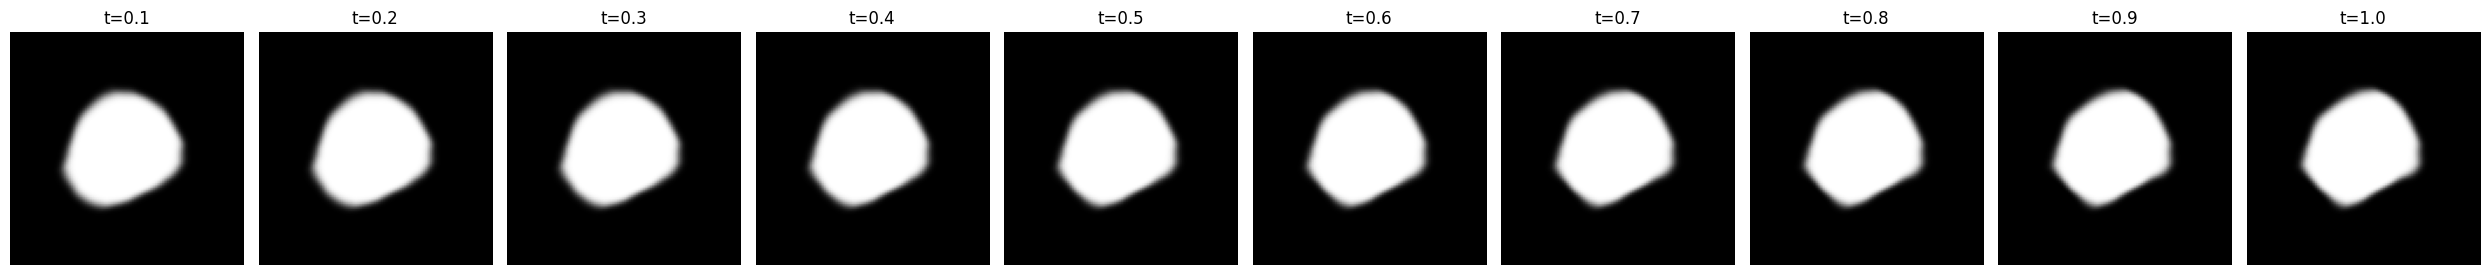

In [260]:
# Final velocity at t = 1
v_t1 = vt_sequence[-1]

# Visualize the final velocity field at t = 1
plt.figure(figsize=(8, 8))

plt.imshow(s, cmap='gray')
plt.quiver(v_t1[..., 1], v_t1[..., 0], color='red')
plt.title('Final Velocity Field at t=1')
plt.axis('off')

# Display the time-sequence of deformed images side by side
num_images = len(deformed_images)  # Number of images to plot
fig, axes = plt.subplots(1, num_images, figsize=(25,10))  # Create a row of subplots

for idx, img in enumerate(deformed_images):
    ax = axes[idx]  # Get the correct subplot axis
    ax.imshow(img, cmap='gray')
    ax.set_title(f't={time_points[idx+1]:.1f}')  # Set title with the corresponding time point
    ax.axis('off')  # Hide the axis
    
plt.tight_layout()  # Adjust layout so the images don't overlap
plt.show()


#### The final velocity field at $t = 1$ is displayed as a vector field over the source image. The red arrows represent the direction and magnitude of the velocity at each point in the image at time $t = 1$. The time-sequence of deformed images shows the source image deformed at different time points from $t = 0$ to $t = 1$. Even though you can't see the deformation clearly between two consecutive images, the deformation is accumulated over time, and the final deformed image at $t=1$ has significant deformation compared to the original source image.

#### Displaying the source and final deformed images to visualize the deformation clearly

(np.float64(-0.5), np.float64(99.5), np.float64(99.5), np.float64(-0.5))

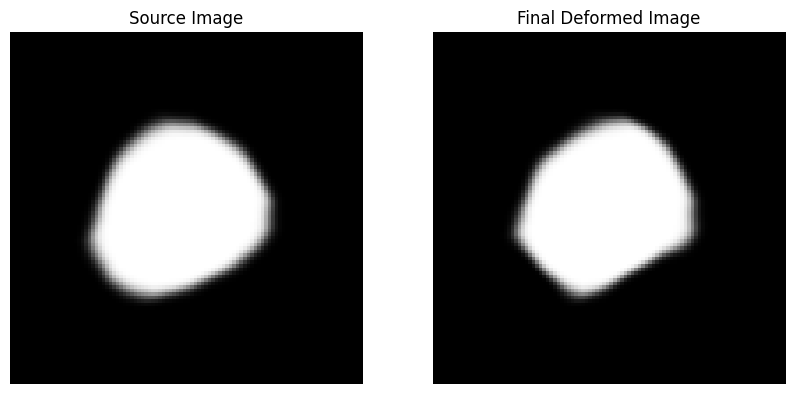

In [261]:
# displaying the Source and final deformed images
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title('Source Image')
plt.imshow(s, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Final Deformed Image')
plt.imshow(deformed_images[-1], cmap='gray')
plt.axis('off')

#### Subtracting the original image from the final deformed image to show the difference

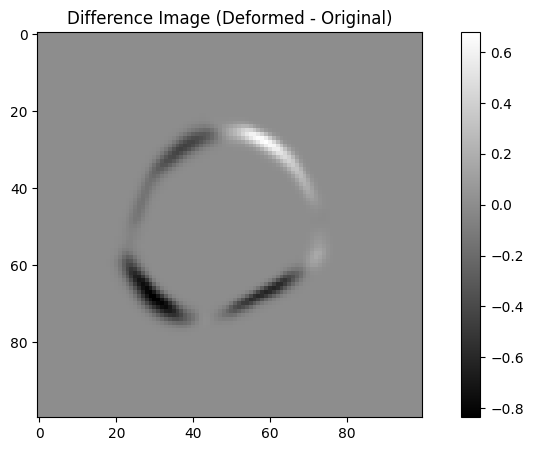

In [262]:
# subtracting the original image from the deformed image to see the difference
deformed_image = deformed_images[-1]
diff_image = deformed_image - s

# Display the difference image
plt.figure(figsize=(10, 5))
plt.imshow(diff_image, cmap='gray')
plt.title('Difference Image (Deformed - Original)')
plt.colorbar()
plt.show()

#### Here we can see that the final deformed image is the result of applying the transformation to the source image. The difference image shows the changes that have occurred due to the deformation. We can clearly see some significant differences in the regions where the deformation has been applied.

#### Part (c)
Report the total running time of your shooting algorithm.

In [263]:
total_time = end_time - start_time
print(f"Total running time: {total_time:.5f} seconds")

Total running time: 0.03730 seconds


Part (d) of the question is answered after question 3

### Question 3

Compute the inverse transformation $\phi_1^{-1}$ at time point $t=1$ by the following strategy.

$$
\frac{dv_t}{dt} = K[(Dv_t)^T \cdot v_t + (Dv_t) \cdot v_t + v_t \cdot \text{div}(v_t)],
$$
$$
\frac{d\phi_t^{-1}}{dt} = -D \phi_t^{-1} \cdot v_t,
$$

Report the deformed source image using $\phi_1^{-1}$ , and describe how it is diﬀerent from the final deformed image in problem 2.

#### Implementing the inverse transformation algorithm using Euler integration and computing the deformed image using $\phi_1^{-1}$ 

#### First we initialize the variables with velocity field $v_0$ and the identity mapping $\phi_0$

In [264]:
# Initialize variables
vt = v0.copy()

vt_sequence_inv = [vt.copy()]

# Initialize the inverse transformation at t = 0
phi_inv = phi0.copy()  # Identity mapping at t = 0

phi_inv_sequence = [phi_inv.copy()]

#### Euler integration loop to compute $\phi_1^{-1}$ from $t = 0$ to $t = 1$

In [265]:
# Euler integration loop to compute phi_inv from t = 0 to t = 1
for t_idx in range(num_time_steps):
    print(f"Inverse Time step {t_idx+1}/{num_time_steps}")
    
    # Compute the Jacobian Dvt
    Dvt = compute_jacobian(vt)

    # Compute divergence of vt
    div_vt = compute_divergence(vt)

    # Compute the right-hand side of the velocity equation
    # (Dv_t)^T · v_t
    Dvt_T_vt = np.einsum('...ji,...j->...i', Dvt, vt)

    # (Dv_t) · v_t
    Dvt_vt = np.einsum('...ij,...j->...i', Dvt, vt)

    # v_t · div(v_t)
    vt_div_vt = vt * div_vt[..., np.newaxis]

    # Sum the terms
    F_t = Dvt_T_vt + Dvt_vt + vt_div_vt

    # Apply the smoothing kernel K[F_t]
    K_F_t = apply_smoothing_kernel(F_t, sigma=sigma_smoothing)
    
    # Update the velocity field vt
    vt = vt + delta_t * K_F_t
    
    # Compute the gradient of phi_inv (Dphi_inv)
    # Dphi_inv is a tensor of shape (H, W, 2, 2)
    Dphi_inv = np.zeros((height, width, 2, 2))
    
    # Compute derivatives of phi_inv components
    Dphi_inv[..., 0, 0] = np.gradient(phi_inv[..., 0], axis=0)  # d(phi_inv_y)/dy
    Dphi_inv[..., 0, 1] = np.gradient(phi_inv[..., 0], axis=1)  # d(phi_inv_y)/dx
    Dphi_inv[..., 1, 0] = np.gradient(phi_inv[..., 1], axis=0)  # d(phi_inv_x)/dy
    Dphi_inv[..., 1, 1] = np.gradient(phi_inv[..., 1], axis=1)  # d(phi_inv_x)/dx
    
    # Compute Dphi_inv · vt
    Dphi_inv_vt = np.einsum('...ij,...j->...i', Dphi_inv, vt)
    
    # Update phi_inv using Euler's method
    phi_inv = phi_inv - delta_t * Dphi_inv_vt
    
    # Store phi_inv for later use
    phi_inv_sequence.append(phi_inv.copy())
    # Store the inverse velocity field
    vt_sequence_inv.append(vt.copy())


Inverse Time step 1/10
Inverse Time step 2/10
Inverse Time step 3/10
Inverse Time step 4/10
Inverse Time step 5/10
Inverse Time step 6/10
Inverse Time step 7/10
Inverse Time step 8/10
Inverse Time step 9/10
Inverse Time step 10/10


#### Get the inverse transformation and the image at $t = 1$

In [266]:
# Get the inverse transformation at t = 1
phi_inv_t1 = phi_inv_sequence[-1]

deformed_image_phi_inv = scipy.ndimage.map_coordinates(
    s,
    [phi_inv_t1[..., 0], phi_inv_t1[..., 1]],
    order=3,
    mode='reflect'
)

#### Plotting the source image, forward deformed image at $t = 1$, and inverse deformed image at $t = 1$

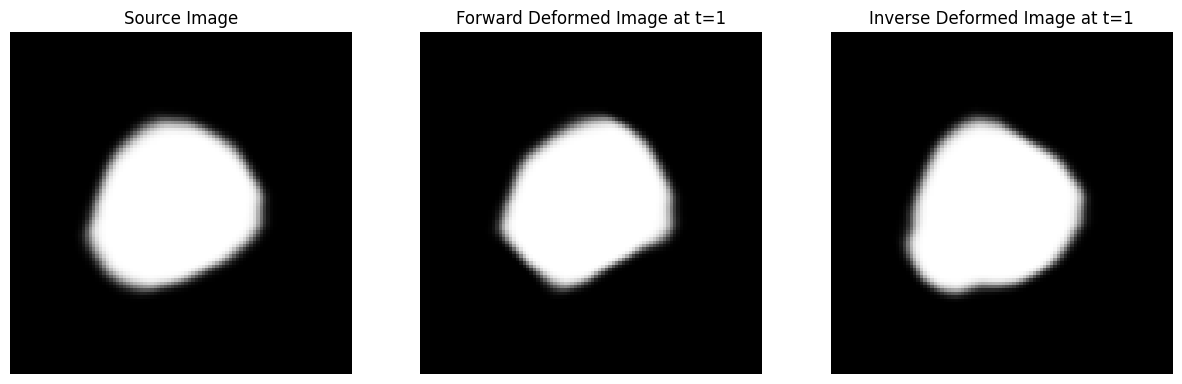

In [267]:
# Deformed image from the forward integration at t = 1
deformed_image_forward_t1 = deformed_images[-1]  # Assuming deformed_images is from the forward integration

# Displaying the source image, forward deformed image, and inverse deformed image
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title('Source Image')
plt.imshow(s, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Forward Deformed Image at t=1')
plt.imshow(deformed_image_forward_t1, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Inverse Deformed Image at t=1')
plt.imshow(deformed_image_phi_inv, cmap='gray')
plt.axis('off')

plt.show()

#### Displaying the difference between the forward deformed image at $t = 1$ and the inverse deformed image at $t = 1$

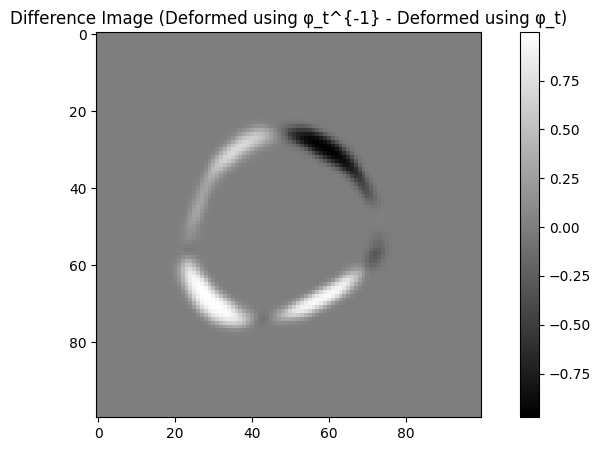

In [268]:
# displaying the difference between the two images
diff_image_inv = deformed_image_phi_inv - deformed_image
plt.figure(figsize=(10, 5))
plt.imshow(diff_image_inv, cmap='gray')
plt.title('Difference Image (Deformed using φ_t^{-1} - Deformed using φ_t)')
plt.colorbar()
plt.show()

#### As you can observe, the difference between the forward and inverse deformed images is quite clear. The difference shows that the whatever the deformation the forward transformation applied to the source image, the inverse transformation tries to reverse it. This can be seen especially in the regions of the image where there is significant deformation. For example if the forward transformation compresses a region, the inverse transformation will try to expand that particular region. This is because the inverse goes in the opposite direction of the forward transformation on the manifold with the same velocity tangent.

#### Let us try to check if our transformations are correct by applying the inverse transformation to the forward deformed image and see if we get the source image back.

#### We will set the initial velocity to the final velocity field since it is the tangent vector to the geodesic at time t=1 in the forward direction. We don't need to reverse the tangent vector since the inverse transformation dv/dt = K[(Dv)^T · v + (Dv) · v + v · div(v)] will automatically reverse the direction.

In [269]:
# Initialize variables

# setting delta_t to 1/num_time_steps make the image approximation better.
num_time_steps = 1000
delta_t = 1.0 / num_time_steps


vt = vt_sequence[-1].copy()

# Reverse the time steps and velocity sequence
vt_sequence_inv = [vt.copy()]

# Initialize the inverse transformation at t = 0
phi_inv = phi0.copy()  # Identity mapping at t = 0

phi_inv_sequence = [phi_inv.copy()]

In [270]:
# Euler integration loop to compute phi_inv from t = 0 to t = 1
for t_idx in range(num_time_steps):
    print(f"Inverse Time step {t_idx+1}/{num_time_steps}")

    # Compute the Jacobian Dvt
    Dvt = compute_jacobian(vt)

    # Compute divergence of vt
    div_vt = compute_divergence(vt)

    # Compute the right-hand side of the velocity equation
    # (Dv_t)^T · v_t
    Dvt_T_vt = np.einsum('...ji,...j->...i', Dvt, vt)

    # (Dv_t) · v_t
    Dvt_vt = np.einsum('...ij,...j->...i', Dvt, vt)

    # v_t · div(v_t)
    vt_div_vt = vt * div_vt[..., np.newaxis]

    # Sum the terms
    F_t = Dvt_T_vt + Dvt_vt + vt_div_vt

    # Apply the smoothing kernel K[F_t]
    K_F_t = apply_smoothing_kernel(F_t, sigma=sigma_smoothing)

    # Update the velocity field vt
    vt = vt + delta_t * K_F_t

    # Compute the gradient of phi_inv (Dphi_inv)
    # Dphi_inv is a tensor of shape (H, W, 2, 2)
    Dphi_inv = np.zeros((height, width, 2, 2))

    # Compute derivatives of phi_inv components
    Dphi_inv[..., 0, 0] = np.gradient(phi_inv[..., 0], axis=0)  # d(phi_inv_y)/dy
    Dphi_inv[..., 0, 1] = np.gradient(phi_inv[..., 0], axis=1)  # d(phi_inv_y)/dx
    Dphi_inv[..., 1, 0] = np.gradient(phi_inv[..., 1], axis=0)  # d(phi_inv_x)/dy
    Dphi_inv[..., 1, 1] = np.gradient(phi_inv[..., 1], axis=1)  # d(phi_inv_x)/dx

    # Compute Dphi_inv · vt
    Dphi_inv_vt = np.einsum('...ij,...j->...i', Dphi_inv, vt)

    # Update phi_inv using Euler's method
    phi_inv = phi_inv - delta_t * Dphi_inv_vt

    # Store phi_inv for later use
    phi_inv_sequence.append(phi_inv.copy())
    # Store the inverse velocity field
    vt_sequence_inv.append(vt.copy())


Inverse Time step 1/1000
Inverse Time step 2/1000
Inverse Time step 3/1000
Inverse Time step 4/1000
Inverse Time step 5/1000
Inverse Time step 6/1000
Inverse Time step 7/1000
Inverse Time step 8/1000
Inverse Time step 9/1000
Inverse Time step 10/1000
Inverse Time step 11/1000
Inverse Time step 12/1000
Inverse Time step 13/1000
Inverse Time step 14/1000
Inverse Time step 15/1000
Inverse Time step 16/1000
Inverse Time step 17/1000
Inverse Time step 18/1000
Inverse Time step 19/1000
Inverse Time step 20/1000
Inverse Time step 21/1000
Inverse Time step 22/1000
Inverse Time step 23/1000
Inverse Time step 24/1000
Inverse Time step 25/1000
Inverse Time step 26/1000
Inverse Time step 27/1000
Inverse Time step 28/1000
Inverse Time step 29/1000
Inverse Time step 30/1000
Inverse Time step 31/1000
Inverse Time step 32/1000
Inverse Time step 33/1000
Inverse Time step 34/1000
Inverse Time step 35/1000
Inverse Time step 36/1000
Inverse Time step 37/1000
Inverse Time step 38/1000
Inverse Time step 39/

In [271]:
# Get the inverse transformation at t = 1
phi_inv_t1 = phi_inv_sequence[-1]

In [272]:
# applying the phi_inv on the deformed image
deformed_image_phi_inv = scipy.ndimage.map_coordinates(
    deformed_image_forward_t1,
    [phi_inv_t1[..., 0], phi_inv_t1[..., 1]],
    order=3,
    mode='reflect'
)

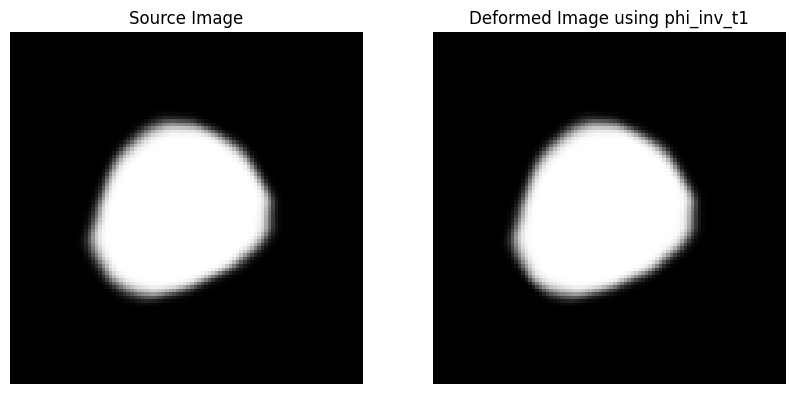

In [273]:
# Display the deformed image using phi_inv_t1 and the source image
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title('Source Image')
plt.imshow(s, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Deformed Image using phi_inv_t1')
plt.imshow(deformed_image_phi_inv, cmap='gray')
plt.axis('off')

plt.show()

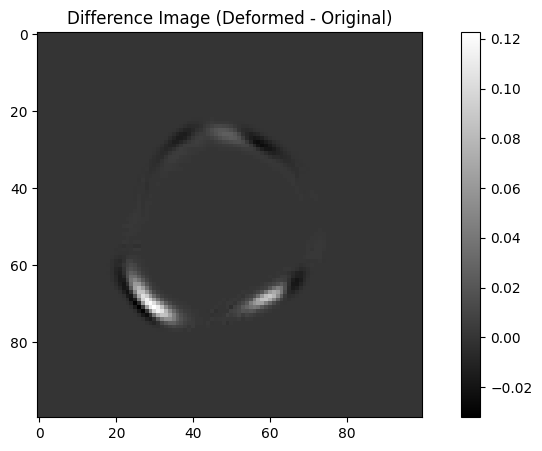

In [274]:
# subtracting the source image from the deformed image
diff_image = deformed_image_phi_inv - s

# Display the difference image
plt.figure(figsize=(10, 5))
plt.imshow(diff_image, cmap='gray')
plt.title('Difference Image (Deformed - Original)')
plt.colorbar()
plt.show()

#### We have used 1000 time steps in this experiment to make the approximation more better. As you can clearly see from the difference image that the inverse transformation $\phi_1^{-1}$ applied to the forward deformed image at $t = 1$ gives us the source image back in a decent way from the eye test. This shows that the inverse transformation is able to reverse the deformation applied by the forward transformation. The difference image is also almost zero, indicating that the deformed image using the inverse transformation is very close to the original source image. From this, we can conclude that both the forward and inverse transformations are working correctly.

### Question 2 - Part (d)

Now generate your own random initial velocity field by computing $ϵ·∇s$, where $ϵ$ denotes
randomly generated velocity fields drawn from a normal Gaussian distribution followed
by being smoothed by a Gaussian kernel (try diﬀerent smoothing variances with values
of 2.0,4.0,8.0). Repeat (a)-(b).

#### Generating a random initial velocity field and repeating the geodesic shooting algorithm


---
Using smoothing variance: 2.0
Time step 1/10 for variance 2.0
Time step 2/10 for variance 2.0
Time step 3/10 for variance 2.0
Time step 4/10 for variance 2.0
Time step 5/10 for variance 2.0
Time step 6/10 for variance 2.0
Time step 7/10 for variance 2.0
Time step 8/10 for variance 2.0
Time step 9/10 for variance 2.0
Time step 10/10 for variance 2.0
Total running time with variance 2.0: 0.03 seconds


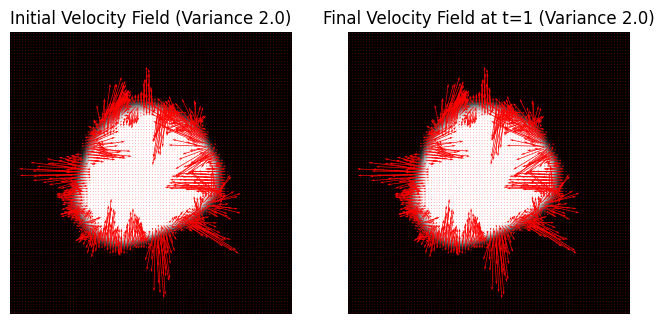

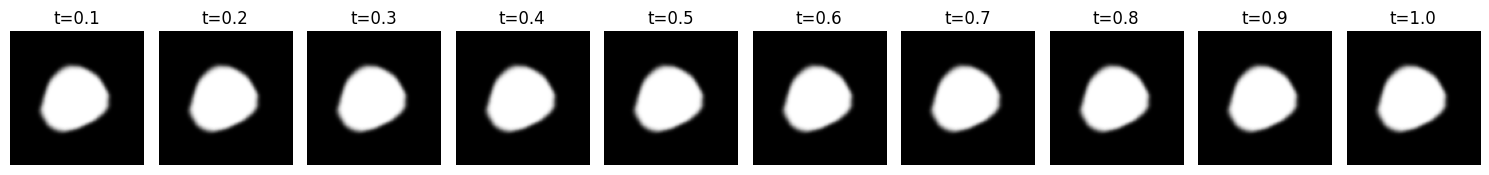


---
Using smoothing variance: 4.0
Time step 1/10 for variance 4.0
Time step 2/10 for variance 4.0
Time step 3/10 for variance 4.0
Time step 4/10 for variance 4.0
Time step 5/10 for variance 4.0
Time step 6/10 for variance 4.0
Time step 7/10 for variance 4.0
Time step 8/10 for variance 4.0
Time step 9/10 for variance 4.0
Time step 10/10 for variance 4.0
Total running time with variance 4.0: 0.03 seconds


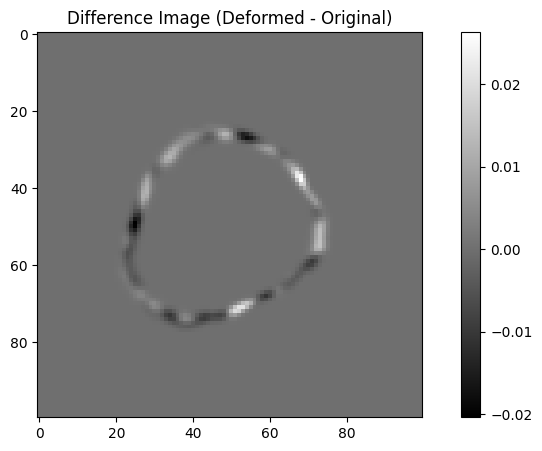

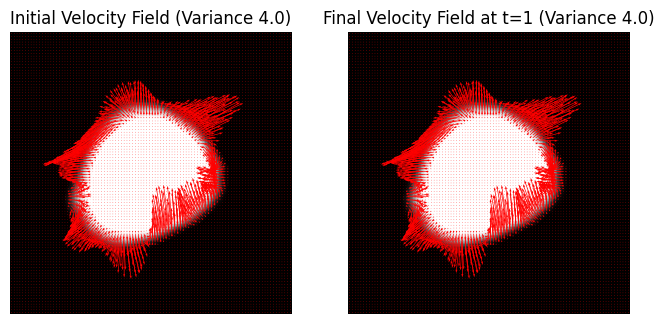

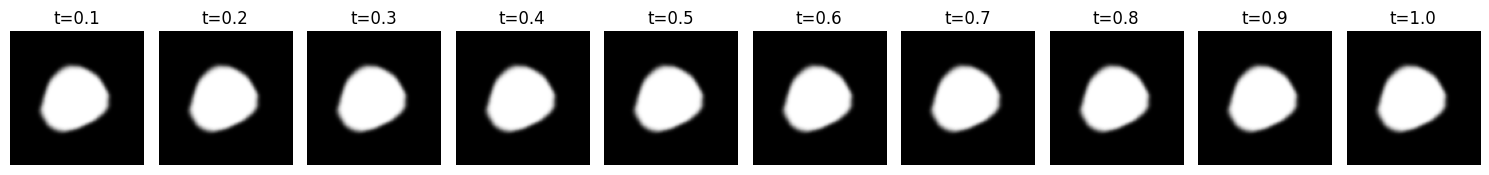


---
Using smoothing variance: 8.0
Time step 1/10 for variance 8.0
Time step 2/10 for variance 8.0
Time step 3/10 for variance 8.0
Time step 4/10 for variance 8.0
Time step 5/10 for variance 8.0
Time step 6/10 for variance 8.0
Time step 7/10 for variance 8.0
Time step 8/10 for variance 8.0
Time step 9/10 for variance 8.0
Time step 10/10 for variance 8.0
Total running time with variance 8.0: 0.03 seconds


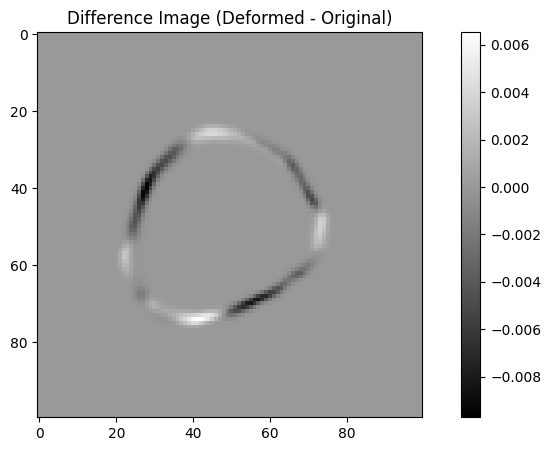

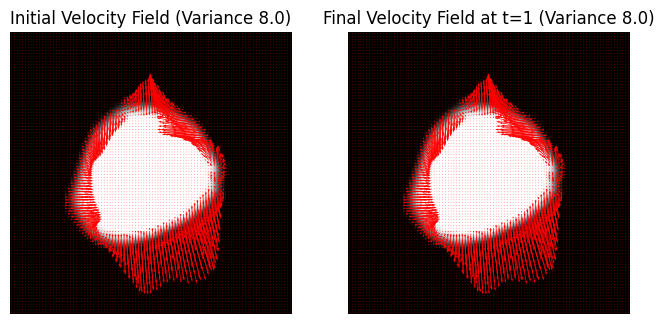

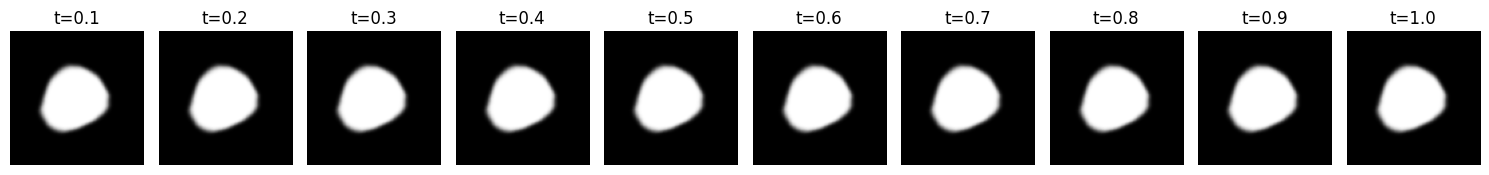

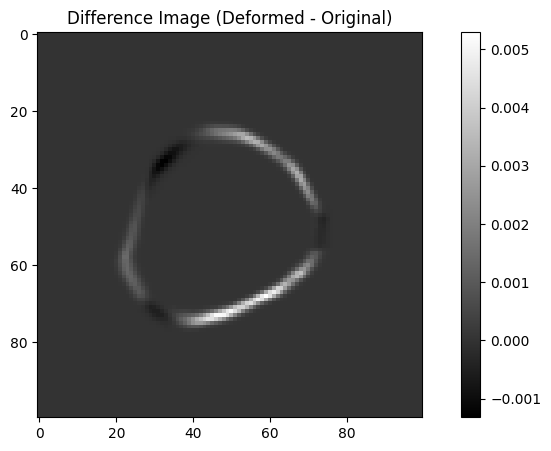

In [275]:
# Smoothing variances to try
smoothing_variances = [2.0, 4.0, 8.0]

num_time_steps = 10
delta_t = 1.0 / num_time_steps

for variance in smoothing_variances:
    print(f"\n---\nUsing smoothing variance: {variance}")

    # Generate random velocity field epsilon
    epsilon = np.random.normal(size=(height, width, 2))
    epsilon_smoothed = apply_smoothing_kernel(epsilon, sigma=variance)

    # Compute the gradient of the source image
    grad_s_y, grad_s_x = np.gradient(s)
    # Combine the gradients to get the gradient field
    grad_s = np.stack((grad_s_y, grad_s_x), axis=-1)
    
    # # you can also try putting grad_s as a stack of 2 magnitudes
    # grad_s_magnitude = np.linalg.norm(grad_s, axis=-1)
    # grad_s = np.stack((grad_s_magnitude, grad_s_magnitude), axis=-1)

    # setting the velocity factor to 1 so as to try to introduce more deformation
    # You can also try different velocity factors if you want to see more deformation
    velocity_factor = 1

    # Compute the new initial velocity field v0 = epsilon * grad_s
    v0_random = epsilon_smoothed * grad_s * velocity_factor

    # Re-initialize variables
    vt = v0_random.copy()
    phit = phi0.copy()

    vt_sequence = [vt.copy()]
    phit_sequence = [phit.copy()]
    deformed_images = []

    # Start timing
    start_time = time.time()

    # Euler integration loop
    for t_idx in range(num_time_steps):
        print(f"Time step {t_idx+1}/{num_time_steps} for variance {variance}")

        # Compute the Jacobian Dvt
        Dvt = compute_jacobian(vt)

        # Compute divergence of vt
        div_vt = compute_divergence(vt)

        # Compute the right-hand side of the velocity equation
        # (Dv_t)^T · v_t
        Dvt_T_vt = np.einsum('...ji,...j->...i', Dvt, vt)

        # (Dv_t) · v_t
        Dvt_vt = np.einsum('...ij,...j->...i', Dvt, vt)

        # v_t · div(v_t)
        vt_div_vt = vt * div_vt[..., np.newaxis]

        # Sum the terms
        F_t = Dvt_T_vt + Dvt_vt + vt_div_vt

        # Apply the smoothing kernel K[F_t]
        K_F_t = apply_smoothing_kernel(F_t, sigma=sigma_smoothing)

        # Update the velocity field vt
        vt = vt - delta_t * K_F_t

        # Interpolate vt over phit
        vt_phi = interpolate(vt, phit)

        # Update the transformation phit
        phit = phit + delta_t * vt_phi

        # Store intermediate results
        vt_sequence.append(vt.copy())
        phit_sequence.append(phit.copy())

        # Deform the source image
        deformed_image = scipy.ndimage.map_coordinates(
            s,
            [phit[..., 0], phit[..., 1]],
            order=3,
            mode='reflect'
        )
        deformed_images.append(deformed_image)

    # End timing
    end_time = time.time()
    total_time = end_time - start_time
    print(f"Total running time with variance {variance}: {total_time:.2f} seconds")

    # Display the initial and final velocity fields
    plt.figure(figsize=(8, 8))
    
    plt.subplot(1, 2, 1)
    plt.imshow(s, cmap='gray')
    plt.quiver(v0_random[..., 1], v0_random[..., 0], color='red')
    plt.title(f'Initial Velocity Field (Variance {variance})')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(s, cmap='gray')
    plt.quiver(vt_sequence[-1][..., 1], vt_sequence[-1][..., 0], color='red')
    plt.title(f'Final Velocity Field at t=1 (Variance {variance})')
    plt.axis('off')
    
    
    # Display the time-sequence of deformed images side by side
    num_images = len(deformed_images)  # Number of images to plot
    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))  # Create a row of subplots
    
    for idx, img in enumerate(deformed_images):
        ax = axes[idx]  # Get the correct subplot axis
        ax.imshow(img, cmap='gray')
        ax.set_title(f't={time_points[idx+1]:.1f}')  # Set title with the corresponding time point
        ax.axis('off')  # Hide the axis
        
    plt.tight_layout()  # Adjust layout so the images don't overlap
    plt.show()
    
        
    # subtracting the original image from the deformed image
    deformed_image = deformed_images[-1]
    diff_image = deformed_image - s
    
    # Display the difference image
    plt.figure(figsize=(10, 5))
    plt.imshow(diff_image, cmap='gray')
    plt.title('Difference Image (Deformed - Original)')
    plt.colorbar()


#### As you can see the random velocity field initialized with different smoothing variances doesn't give much of a difference in the final deformed image. And the initial and final vector fields are also not very different. However you can use higher velocity factors to see more deformation in the final deformed image since it increases the magnitude of the initial velocity field.


#### *Programming Assisted By ChatGPT and Github Copilot